In [19]:
from kan import KAN, LBFGS, MLP
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from tqdm import tqdm

device = torch.device('cpu')
print(device)

cpu


In [24]:
dim = 2
ranges = [-1, 1]
n_train = 1000
n_test = 200
steps = 100
grids = [5, 10, 20, 50, 100]

In [ ]:
def sol_fun(x):
    half = x.shape[1] // 2
    m = x[:, :half]
    v = x[:, half:2*half]
    return torch.sum(0.5 * m * (v ** 2), dim=1, keepdim=True)

In [26]:
x_train = torch.rand((n_train, dim), device=device) * 2 - 1
y_train = sol_fun(x_train)
x_test = torch.rand((n_test, dim), device=device) * 2 - 1
y_test = sol_fun(x_test)
criterion = torch.nn.MSELoss()

In [27]:
def train_model(static=True, width=[dim, 10, 1]):
    mses = []
    r2s = []
    preds = []
    param_counts = []
    for grid in grids:
        if grid == grids[0]:
            model = KAN(width=width, grid=grid, k=3, seed=1, device=device)
            model = model.speed()
        else:
            model.save_act = True
            model.get_act(x_train)
            model = model.refine(grid)
            model = model.speed()
        num_params = sum(1 for _ in model.parameters())
        param_counts.append(num_params)

        def train():
            optimizer = LBFGS(
                    model.parameters(), 
                    lr=0.1, 
                    history_size=10, 
                    line_search_fn="strong_wolfe",
                    tolerance_grad=1e-32, 
                    tolerance_change=1e-32, 
                    tolerance_ys=1e-32
                )
            pbar = tqdm(range(steps), desc='description', ncols=100)

            for _ in pbar:
                def closure():
                    optimizer.zero_grad()
                    loss = criterion(model(x_train), y_train)
                    loss.backward()
                    return loss

                if _ % (steps//10)== 0 and _ < steps // 2:
                    model.update_grid_from_samples(x_train)

                optimizer.step(closure)
                with torch.no_grad():
                    test_pred = model(x_test)
                    mse = criterion(test_pred, y_test).item()
                    r2 = r2_score(y_test.cpu().numpy(), test_pred.cpu().numpy())

                pbar.set_description("mse: %.2e | r2: %.2e " % (mse, r2))

                mses.append(mse)
                r2s.append(r2)
                preds.append(test_pred)
                
            
        train()
        if static:
            break
    return mses, r2s, preds, param_counts

In [43]:
def plot_results(mses, r2s):
    rmses = [mse ** 0.5 for mse in mses]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(r2s, marker='o')
    ax1.set_xlabel('steps')
    ax1.legend(['R2 score'])
    rmses = [mse ** 0.5 for mse in mses]
    ax2.plot(rmses, marker='o')
    ax2.set_yscale('log')
    ax2.set_xlabel('steps')
    ax2.legend(['RMSE'])
    plt.tight_layout()
    print("Final RMSE: %.2e" % rmses[-1])

In [29]:
mses, r2s, preds, param_counts = train_model(static=True, width=[2, 2, 1])

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

mse: 1.74e-06 | r2: 1.00e+00 : 100%|██████████████████████████████| 100/100 [00:40<00:00,  2.45it/s]


Final RMSE: 1.32e-03


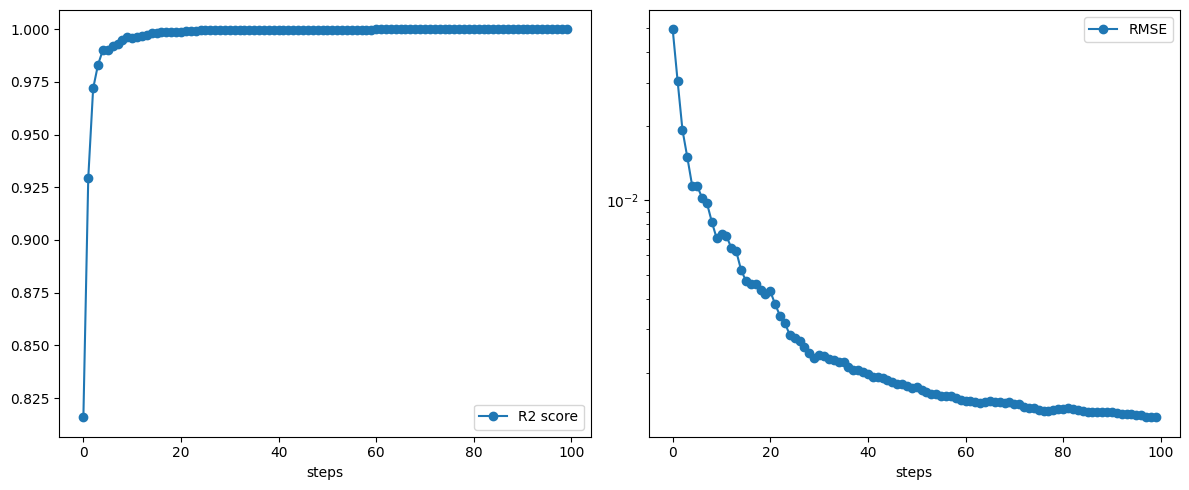

In [44]:
plot_results(mses, r2s)

In [30]:
import numpy as np
np.savez('physics-kan.npz', mses=mses, r2s=r2s, preds=preds, param_counts=param_counts, test=x_test)

In [31]:
print(param_counts)

[22]


In [32]:
mlp_hidden_width = (param_counts[0] - 1) // 4
mlp_width_config = [2, mlp_hidden_width, 1]
mlp_model = MLP.MLP(width=mlp_width_config, act='silu', device='cpu')
mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(mlp_params)

21


In [40]:
dataset = {
    'train_input': x_train,
    'train_label': y_train,
    'test_input': x_test,
    'test_label': y_test
}
def r2():
    with torch.no_grad():
        pred = mlp_model(dataset['test_input'].to(mlp_model.device))
        target = dataset['test_label'].to(mlp_model.device)
        ss_res = torch.sum((target - pred) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return 1 - (ss_res / ss_tot)

In [41]:
mlp_results = mlp_model.fit(dataset, opt="LBFGS", steps=100, lr=0.1, metrics=[r2])

| train_loss: 1.86e-03 | test_loss: 1.57e-03 | reg: 3.04e+01 | : 100%|█| 100/100 [00:02<00:00, 43.61


Final RMSE: 3.96e-02


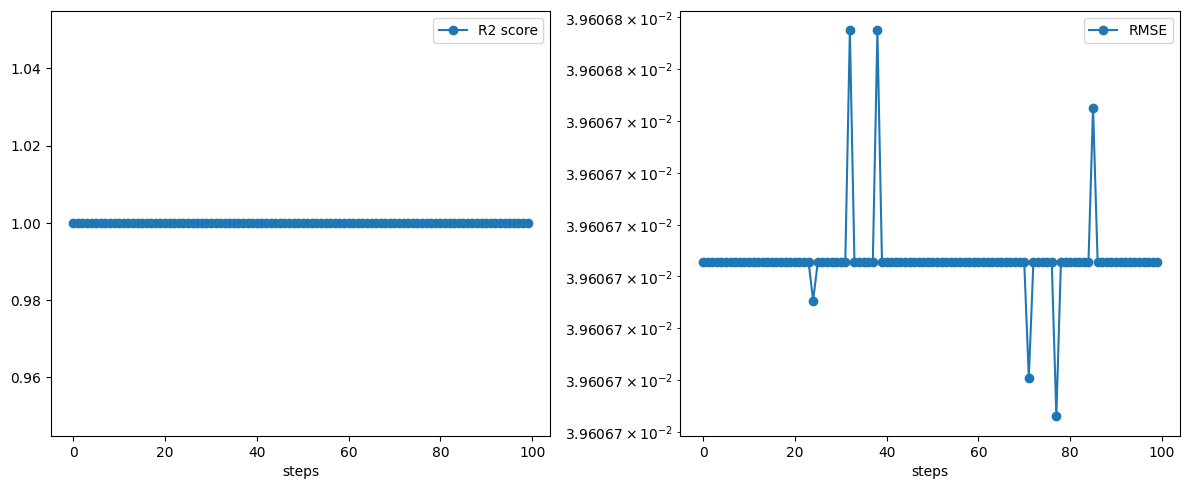

In [45]:
plot_results(mlp_results['test_loss'], mlp_results['r2'])